# Description of NLPCSS-20 Corpus

## Importing and Loading

In [4]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("../data/raw/released_data.json")

df = pd.read_json(DATA_PATH, lines=True)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("\nColumn names:")
print(df.columns.tolist())

Rows: 7775
Columns: 8

Column names:
['source', 'title', 'event_id', 'adfontes_fair', 'adfontes_political', 'allsides_bias', 'content', 'misc']


## Inspecting metadata `misc`

In [5]:
print(type(df.loc[0, "misc"]))
print(df.loc[0, "misc"])

<class 'dict'>
{'time': '2019-01-28 16:10:44.680484', 'topics': 'Election: Presidential', 'author': ['Brooke Singman', '| Fox News']}


## `misc` into separate columns

In [6]:
misc_df = pd.json_normalize(df["misc"])

df = pd.concat(
    [
        df.drop(columns=["misc"]).reset_index(drop=True),
        misc_df.reset_index(drop=True)
    ],
    axis=1
)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values in metadata:")
print(df[["time", "topics", "author"]].isna().sum())

Rows: 7775
Columns: 12

Column names:
['source', 'title', 'event_id', 'adfontes_fair', 'adfontes_political', 'allsides_bias', 'content', 'time', 'topics', 'author', 'summary', 'subtitle']

Missing values in metadata:
time      386
topics      0
author    506
dtype: int64


In [7]:
topics = df["topics"].astype("string")

print("Actual NaN values:", df["topics"].isna().sum())
print("Empty/whitespace strings:", topics.str.strip().eq("").sum())
print(
    "Text placeholders (nan/none/null):",
    topics.str.strip().str.lower().isin(["nan", "none", "null"]).sum()
)
print("Unique topic values:", df["topics"].nunique(dropna=False))

Actual NaN values: 0
Empty/whitespace strings: 40
Text placeholders (nan/none/null): 0
Unique topic values: 184


In [8]:
df["topics"] = df["topics"].replace(r"^\s*$", pd.NA, regex=True)

print("Missing topics after standardisation:", df["topics"].isna().sum())

Missing topics after standardisation: 40


In [11]:
EVAL_SAMPLE_PATH = Path("../data/raw/validation_sample_45_articles.csv")

eval_df = pd.read_csv(EVAL_SAMPLE_PATH)

print("Evaluation sample rows:", len(eval_df))
print("Columns:")
print(eval_df.columns.tolist())

Evaluation sample rows: 45
Columns:
['original_index', 'source', 'title', 'event_id', 'adfontes_fair', 'adfontes_political', 'allsides_bias', 'content', 'misc', 'topics', 'word_count']


In [13]:
eval_indices = eval_df["original_index"].astype(int)

raw_eval_rows = df.loc[eval_indices].reset_index(drop=True)

print("\nMatches with raw corpus:")
print("Source:", (raw_eval_rows["source"] == eval_df["source"]).sum(), "/ 45")
print("Title:", (raw_eval_rows["title"] == eval_df["title"]).sum(), "/ 45")
print("Event ID:", (raw_eval_rows["event_id"] == eval_df["event_id"]).sum(), "/ 45")
print("Content:", (raw_eval_rows["content"] == eval_df["content"]).sum(), "/ 45")


Matches with raw corpus:
Source: 45 / 45
Title: 42 / 45
Event ID: 45 / 45
Content: 45 / 45


## Removing the 45 articles

In [14]:
df = df.drop(index=eval_indices).copy()

print("Articles after removing evaluation sample:", len(df))
print(
    "Evaluation indices still present:",
    df.index.isin(eval_indices).sum()
)

Articles after removing evaluation sample: 7730
Evaluation indices still present: 0


In [15]:
df["word_count"] = (
    df["content"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

print("Word-count summary:")
print(df["word_count"].describe())

print("\n10 longest articles:")
display(
    df.nlargest(10, "word_count")[
        ["source", "title", "word_count"]
    ]
)

Word-count summary:
count     7730.000000
mean       819.790168
std        944.185652
min          1.000000
25%        451.000000
50%        729.000000
75%       1059.750000
max      69312.000000
Name: word_count, dtype: float64

10 longest articles:


,source,title,word_count
5311,The Nation,"Zephyr Teachout, Hands Up United and John Oliv...",69312
3327,New York Times - News,The Perfect Weapon: How Russian Cyberpower Inv...,7627
4385,Politico,Obama’s State of the Union wins and losses,7395
881,New York Magazine,"David Hogg, After Parkland",7155
2807,Christian Science Monitor,,7116
5791,Vox,An uneasy peace in Ferguson,6674
6966,CNN (Web News),Boston bombings: 'CAPTURED!!! The hunt is over...,6337
1321,Daily Kos,"Morning Digest: With impeachment looming, scan...",6180
3033,Daily Mail,MOST READ NEWS,5809
3533,FactCheck.org,FactChecking the Second Presidential Debate,5754


In [17]:
df = df.drop(index=5311).copy()

print("Articles after removing corrupted article:", len(df))
print("Index 5311 still present:", 5311 in df.index)

Articles after removing corrupted article: 7729
Index 5311 still present: False


In [18]:
short_articles = df[df["word_count"] < 50].copy()

print("Articles shorter than 50 words:", len(short_articles))
print("\nWord-count summary:")
print(short_articles["word_count"].describe())

display(
    short_articles[
        ["source", "title", "topics", "word_count"]
    ].sort_values("word_count")
)

Articles shorter than 50 words: 28

Word-count summary:
count    28.000000
mean     33.357143
std      12.157041
min       1.000000
25%      26.750000
50%      35.500000
75%      43.250000
max      49.000000
Name: word_count, dtype: float64


,source,title,topics,word_count
4841,CNN (Web News),State Dept. spokeswoman sparks Twitter war wit...,State Department,1
4890,New York Times - News,President Obama Is Fired Up and Ready to Tweet,White House,7
4748,Vox,Donald Trump is showing a side of the GOP that...,Election: Presidential,19
4503,Breitbart News,,Violence in America,20
1957,HuffPost,Incredible New Year's Celebrations Around The ...,Holidays,22
2553,The Hill,Senate blocks Trump from making recess appoint...,US Senate,22
3575,Breitbart News,,Election: Presidential,26
5344,Breitbart News,,Election: Presidential,27
6004,The Guardian,Sorry - this page has been removed.,World,30
4361,New York Times - News,Fourth Democratic Debate: Analysis,Election: Presidential,30


In [19]:
df = df[df["word_count"] >= 50].copy()

print("Articles after removing <50-word articles:", len(df))
print("Minimum word count now:", df["word_count"].min())

Articles after removing <50-word articles: 7701
Minimum word count now: 50


In [20]:
duplicate_mask = df.duplicated(subset=["content"], keep="first")

print("Exact-text duplicate articles:", duplicate_mask.sum())

Exact-text duplicate articles: 45


In [22]:
df = df.drop_duplicates(subset=["content"], keep="first").copy()

print("Articles after removing duplicates:", len(df))


Articles after removing duplicates: 7656


In [23]:
print("Articles before topic exclusion:", len(df))
print("Articles with missing topics:", df["topics"].isna().sum())

Articles before topic exclusion: 7656
Articles with missing topics: 40


In [25]:
df = df[df["topics"].notna()].copy()

print("Final corpus:", len(df))
print("Missing topics remaining:", df["topics"].isna().sum())

Final corpus: 7616
Missing topics remaining: 0


## Political-orientation distribution

In [26]:
orientation_counts = df["allsides_bias"].value_counts().sort_index()
orientation_percentages = (
    df["allsides_bias"].value_counts(normalize=True).sort_index() * 100
)

orientation_summary = pd.DataFrame({
    "articles": orientation_counts,
    "percentage": orientation_percentages.round(2)
})

display(orientation_summary)

print("Total:", orientation_summary["articles"].sum())

,articles,percentage
allsides_bias,,
From the Center,1210,15.89
From the Left,3606,47.35
From the Right,2800,36.76


Total: 7616


In [27]:
print("Unique outlets:", df["source"].nunique())

outlet_counts = df["source"].value_counts()

print("\n10 most frequent outlets:")
display(outlet_counts.head(10).to_frame("articles"))

Unique outlets: 110

10 most frequent outlets:


,articles
source,
CNN (Web News),995
Fox News,989
New York Times - News,764
Washington Times,645
HuffPost,530
Politico,424
USA TODAY,347
Townhall,292
The Hill,286


In [28]:
print("Unique topics:", df["topics"].nunique())

topic_counts = df["topics"].value_counts()

print("\n15 most frequent topics:")
display(topic_counts.head(15).to_frame("articles"))

Unique topics: 183

15 most frequent topics:


,articles
topics,
Election: Presidential,1001
Politics,542
White House,503
Immigration,355
Middle East,300
Elections,240
Healthcare,232
US Senate,190
World,189


In [29]:
word_count_summary = df["word_count"].describe()

print("Overall article-length statistics:")
print(word_count_summary)

print("\nMedian word count:", df["word_count"].median())
print("Total word count:", df["word_count"].sum())

Overall article-length statistics:
count    7616.000000
mean      812.540179
std       531.136895
min        50.000000
25%       453.000000
50%       729.000000
75%      1060.000000
max      7627.000000
Name: word_count, dtype: float64

Median word count: 729.0
Total word count: 6188306


In [30]:
length_by_orientation = (
    df.groupby("allsides_bias")["word_count"]
    .agg(
        articles="count",
        mean="mean",
        median="median",
        minimum="min",
        maximum="max",
        total_words="sum"
    )
    .round(2)
)

display(length_by_orientation)

,articles,mean,median,minimum,maximum,total_words
allsides_bias,,,,,,
From the Center,1210,755.01,683.5,65,7116,913562
From the Left,3606,949.73,886.5,51,7627,3424721
From the Right,2800,660.72,598.0,50,5809,1850023


In [31]:
length_by_orientation = (
    df.groupby("allsides_bias")["word_count"]
    .agg(
        articles="count",
        mean="mean",
        median="median",
        minimum="min",
        maximum="max",
        total_words="sum"
    )
    .round(2)
)

display(length_by_orientation)

,articles,mean,median,minimum,maximum,total_words
allsides_bias,,,,,,
From the Center,1210,755.01,683.5,65,7116,913562
From the Left,3606,949.73,886.5,51,7627,3424721
From the Right,2800,660.72,598.0,50,5809,1850023


## Outlets by political orientation

In [33]:
outlets_by_orientation = (
    df.groupby("allsides_bias")["source"]
    .nunique()
    .to_frame("unique_outlets")
)

display(outlets_by_orientation)

,unique_outlets
allsides_bias,
From the Center,25
From the Left,48
From the Right,37


In [34]:
top_outlets_by_orientation = (
    df.groupby(["allsides_bias", "source"])
    .size()
    .reset_index(name="articles")
    .sort_values(
        ["allsides_bias", "articles"],
        ascending=[True, False]
    )
)

top_outlets_by_orientation = (
    top_outlets_by_orientation
    .groupby("allsides_bias")
    .head(5)
)

display(top_outlets_by_orientation)

,allsides_bias,source,articles
24,From the Center,USA TODAY,347
21,From the Center,The Hill,286
18,From the Center,Reuters,184
2,From the Center,BBC News,132
8,From the Center,Christian Science Monitor,97
31,From the Left,CNN (Web News),995
54,From the Left,New York Times - News,764
39,From the Left,HuffPost,530
60,From the Left,Politico,424
72,From the Left,Vox,162


In [35]:
topics_by_orientation = (
    df.groupby("allsides_bias")["topics"]
    .nunique()
    .to_frame("unique_topics")
)

display(topics_by_orientation)

,unique_topics
allsides_bias,
From the Center,121
From the Left,161
From the Right,166


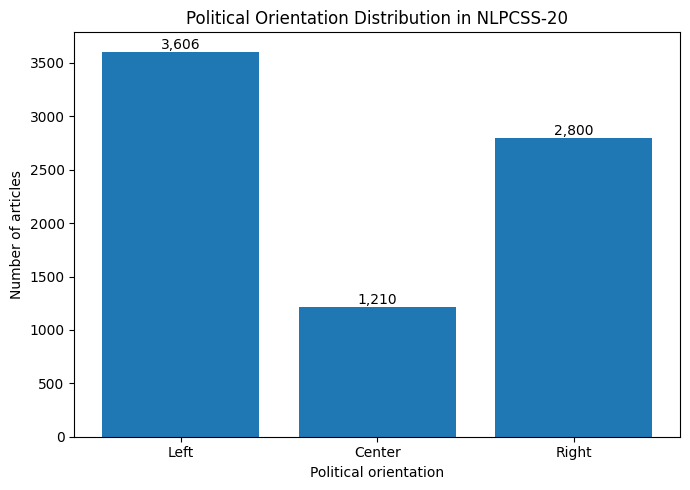

In [36]:
import matplotlib.pyplot as plt

orientation_order = ["From the Left", "From the Center", "From the Right"]

orientation_plot = (
    df["allsides_bias"]
    .value_counts()
    .reindex(orientation_order)
)

labels = ["Left", "Center", "Right"]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(labels, orientation_plot.values)

ax.set_xlabel("Political orientation")
ax.set_ylabel("Number of articles")
ax.set_title("Political Orientation Distribution in NLPCSS-20")

for bar, value in zip(bars, orientation_plot.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "../figures/nlpcss20_political_orientation_distribution.pdf",
    bbox_inches="tight"
)

plt.show()

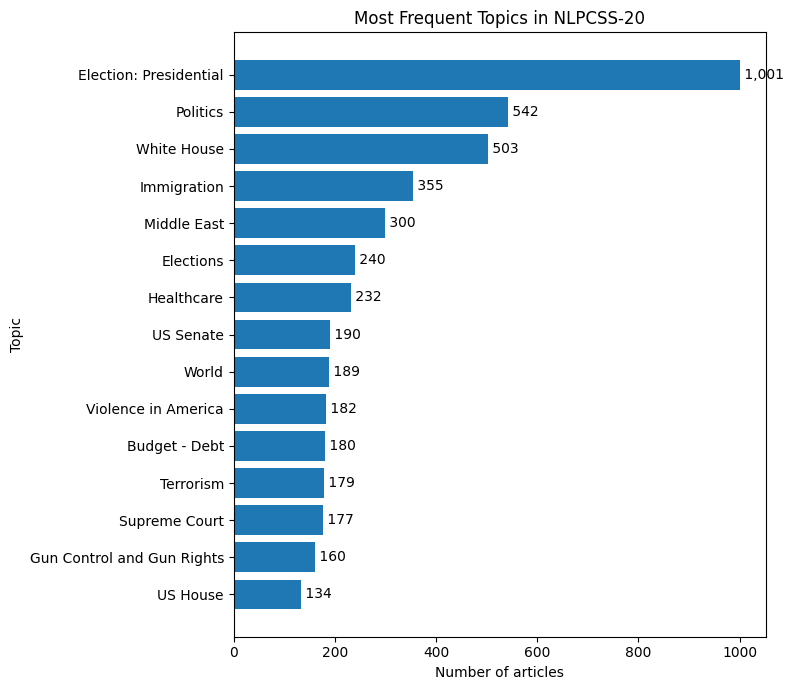

In [37]:
top_topics = (
    df["topics"]
    .value_counts()
    .head(15)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 7))

bars = ax.barh(top_topics.index, top_topics.values)

ax.set_xlabel("Number of articles")
ax.set_ylabel("Topic")
ax.set_title("Most Frequent Topics in NLPCSS-20")

for bar, value in zip(bars, top_topics.values):
    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:,}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "../figures/nlpcss20_topic_distribution.pdf",
    bbox_inches="tight"
)

plt.show()

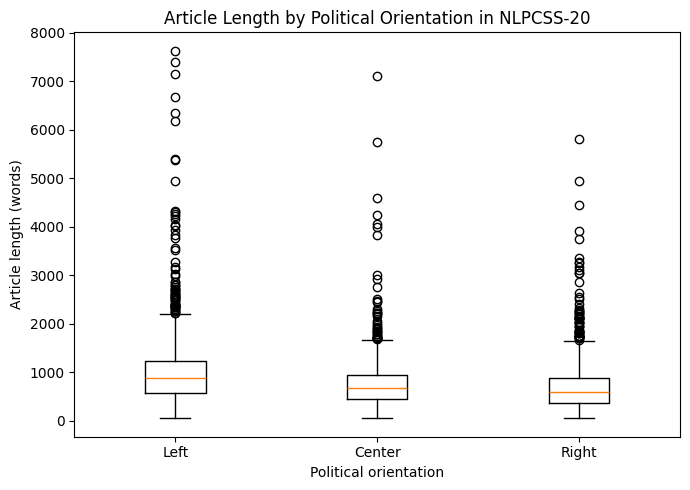

In [38]:
orientation_order = ["From the Left", "From the Center", "From the Right"]
labels = ["Left", "Center", "Right"]

plot_data = [
    df.loc[df["allsides_bias"] == orientation, "word_count"]
    for orientation in orientation_order
]

fig, ax = plt.subplots(figsize=(7, 5))

ax.boxplot(
    plot_data,
    tick_labels=labels
)

ax.set_xlabel("Political orientation")
ax.set_ylabel("Article length (words)")
ax.set_title("Article Length by Political Orientation in NLPCSS-20")

plt.tight_layout()

plt.savefig(
    "../figures/nlpcss20_article_length_by_orientation.pdf",
    bbox_inches="tight"
)

plt.show()

In [39]:
corpus_summary = pd.DataFrame({
    "Corpus property": [
        "Total articles",
        "Unique outlets",
        "Unique topics",
        "Total words",
        "Mean article length",
        "Median article length",
        "Minimum article length",
        "Maximum article length"
    ],
    "Value": [
        len(df),
        df["source"].nunique(),
        df["topics"].nunique(),
        df["word_count"].sum(),
        round(df["word_count"].mean(), 2),
        df["word_count"].median(),
        df["word_count"].min(),
        df["word_count"].max()
    ]
})

display(corpus_summary)

,Corpus property,Value
0,Total articles,7616.00
1,Unique outlets,110.00
2,Unique topics,183.00
3,Total words,6188306.00
4,Mean article length,812.54
5,Median article length,729.00
6,Minimum article length,50.00
7,Maximum article length,7627.00


In [40]:
word_count_table = (
    df.groupby("allsides_bias")["word_count"]
    .agg(
        Articles="count",
        Mean="mean",
        Median="median",
        Minimum="min",
        Maximum="max",
        Total_words="sum"
    )
    .reindex(["From the Left", "From the Center", "From the Right"])
    .rename(index={
        "From the Left": "Left",
        "From the Center": "Center",
        "From the Right": "Right"
    })
)

word_count_table["Mean"] = word_count_table["Mean"].round(2)
word_count_table["Median"] = word_count_table["Median"].round(1)

display(word_count_table)

,Articles,Mean,Median,Minimum,Maximum,Total_words
allsides_bias,,,,,,
Left,3606,949.73,886.5,51,7627,3424721
Center,1210,755.01,683.5,65,7116,913562
Right,2800,660.72,598.0,50,5809,1850023
